#  Cálculo y Visualización de Normales 3D
### Flat Shading vs Smooth Shading con Trimesh y NumPy

---

Este notebook implementa desde cero el cálculo de normales de caras y vértices sobre modelos 3D,
incluyendo validación, corrección de orientación y comparativa visual Flat vs Smooth Shading.

## 0. Instalación de dependencias

In [49]:
# Instalar dependencias si no están disponibles
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    import trimesh
except ImportError:
    install('trimesh[easy]')
    import trimesh


import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


## 1. Carga del Modelo 3D

Puedes cargar cualquier modelo `.obj`, `.stl` o `.gltf`. Si no tienes uno, se genera una esfera de ejemplo.

In [50]:
import os

# ────────────────────────────────────────────────

MODEL_PATH = 'Sting-Sword-lowpoly.obj'
# ────────────────────────────────────────────────

if MODEL_PATH and os.path.exists(MODEL_PATH):
    mesh = trimesh.load(MODEL_PATH)
    print(f'✅ Modelo cargado: {MODEL_PATH}')
else:
    # Genera una esfera subdividida como modelo de demostración
    mesh = trimesh.creation.icosphere(subdivisions=2, radius=1.0)
    print('ℹ  Usando esfera de demostración (icosphere, 2 subdivisiones)')

if isinstance(mesh, trimesh.Scene):
    mesh = mesh.dump(concatenate=True)

print(f'   Vértices : {len(mesh.vertices):,}')
print(f'   Caras    : {len(mesh.faces):,}')
print(f'   Watertight: {mesh.is_watertight}')

vertices = np.array(mesh.vertices)   # (N, 3)
faces    = np.array(mesh.faces)      # (M, 3)

✅ Modelo cargado: Sting-Sword-lowpoly.obj
   Vértices : 1,361
   Caras    : 2,596
   Watertight: False


---
## 2. Cálculo Manual de Normales de Caras

Para cada triángulo $(A, B, C)$:
$$\vec{n} = \frac{(B-A) \times (C-A)}{\|(B-A) \times (C-A)\|}$$

In [51]:
def compute_face_normals(vertices, faces):
    """
    Calcula normales de caras usando producto cruz.

    Returns
    -------
    normals      : (M, 3)  normales unitarias
    areas        : (M,)    área de cada triángulo
    """
    A = vertices[faces[:, 0]]  # (M, 3)
    B = vertices[faces[:, 1]]
    C = vertices[faces[:, 2]]

    v1 = B - A  # (M, 3)
    v2 = C - A  # (M, 3)

    cross = np.cross(v1, v2)          # (M, 3)
    norms = np.linalg.norm(cross, axis=1, keepdims=True)  # (M, 1)

    # Áreas = 0.5 * |v1 × v2|
    areas = 0.5 * norms.squeeze()

    # Evitar división por cero (triángulos degenerados)
    safe_norms = np.where(norms == 0, 1e-10, norms)
    normals = cross / safe_norms      # (M, 3) unitarias

    return normals, areas


face_normals_manual, face_areas = compute_face_normals(vertices, faces)

print(' Normales de caras calculadas manualmente')
print(f'   Shape  : {face_normals_manual.shape}')
print(f'   Min mag: {np.linalg.norm(face_normals_manual, axis=1).min():.6f}')
print(f'   Max mag: {np.linalg.norm(face_normals_manual, axis=1).max():.6f}')

# Comparar con trimesh
face_normals_trimesh = np.array(mesh.face_normals)
dot_products = np.sum(face_normals_manual * face_normals_trimesh, axis=1)
print(f'\n Similitud con trimesh.face_normals:')
print(f'   Dot product mín: {dot_products.min():.6f}')
print(f'   Dot product máx: {dot_products.max():.6f}')
print(f'   Caras alineadas (dot > 0.999): {(dot_products > 0.999).sum()}/{len(faces)}')

 Normales de caras calculadas manualmente
   Shape  : (2596, 3)
   Min mag: 1.000000
   Max mag: 1.000000

 Similitud con trimesh.face_normals:
   Dot product mín: 1.000000
   Dot product máx: 1.000000
   Caras alineadas (dot > 0.999): 2596/2596


### 2.1 Verificar que las normales apunten hacia afuera

In [52]:
def check_outward_normals(vertices, faces, face_normals):
    """
    Verifica si las normales apuntan hacia afuera usando el centroide del mesh.
    Una normal apunta hacia afuera si: (centroide_cara - centroide_mesh) · normal > 0
    """
    # Centroides de cada cara
    A = vertices[faces[:, 0]]
    B = vertices[faces[:, 1]]
    C = vertices[faces[:, 2]]
    face_centroids = (A + B + C) / 3.0  # (M, 3)

    # Centroide global del mesh
    mesh_centroid = vertices.mean(axis=0)  # (3,)

    # Vector del centroide global al centroide de cada cara
    outward_vec = face_centroids - mesh_centroid  # (M, 3)

    # Producto punto con la normal
    dot = np.sum(outward_vec * face_normals, axis=1)  # (M,)

    outward_count  = (dot > 0).sum()
    inward_count   = (dot < 0).sum()
    total          = len(faces)

    return dot, outward_count, inward_count, total


dot_check, out_n, in_n, total_n = check_outward_normals(vertices, faces, face_normals_manual)

print(' Verificación de orientación de normales:')
print(f'   Apuntan hacia afuera : {out_n}/{total_n} ({100*out_n/total_n:.1f}%)')
print(f'   Apuntan hacia adentro: {in_n}/{total_n} ({100*in_n/total_n:.1f}%)')

if in_n > 0:
    print('⚠️  Hay normales invertidas — se corregirán en el paso de validación (Sección 5)')
else:
    print('✅ Todas las normales apuntan hacia afuera')

 Verificación de orientación de normales:
   Apuntan hacia afuera : 1995/2596 (76.8%)
   Apuntan hacia adentro: 601/2596 (23.2%)
⚠️  Hay normales invertidas — se corregirán en el paso de validación (Sección 5)


### 2.2 Visualización de normales de caras

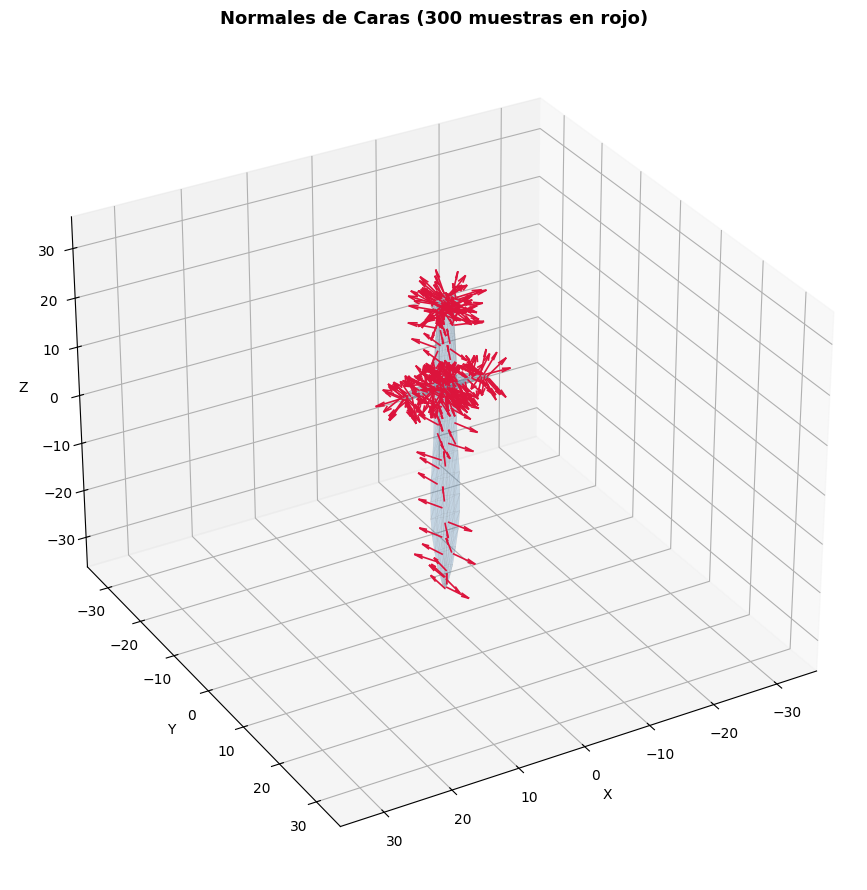

In [67]:
import matplotlib.pyplot as plt

def plot_face_normals(vertices, faces, face_normals, sample_n=150, scale=0.5, elev=30, azim=60):
    """Visualiza el mesh con flechas de normales de caras."""
    A = vertices[faces[:, 0]]
    B = vertices[faces[:, 1]]
    C = vertices[faces[:, 2]]
    centroids = (A + B + C) / 3.0

    # Muestra aleatoria para no saturar el gráfico
    rng = np.random.default_rng(42)
    idx = rng.choice(len(faces), size=min(sample_n, len(faces)), replace=False)

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Renderizar mesh con transparencia
    poly = Poly3DCollection(
        [vertices[f] for f in faces],
        alpha=0.15, facecolor='steelblue', edgecolor='gray', linewidth=0.2
    )
    ax.add_collection3d(poly)

    # Flechas de normales
    origins = centroids[idx]
    dirs     = face_normals[idx] * scale
    ax.quiver(
        origins[:, 0], origins[:, 1], origins[:, 2],
        dirs[:, 0],    dirs[:, 1],    dirs[:, 2],
        color='crimson', linewidth=1.2, arrow_length_ratio=0.35
    )

    # Ajuste de ejes basado en el bounding box de los vértices
    min_coords = vertices.min(axis=0)
    max_coords = vertices.max(axis=0)
    range_coords = max_coords - min_coords
    max_range = np.max(range_coords)
    center = (min_coords + max_coords) / 2

    # Establecer límites simétricos alrededor del centro con un poco de padding
    padding = max_range * 0.1
    ax.set_xlim(center[0] - max_range/2 - padding, center[0] + max_range/2 + padding)
    ax.set_ylim(center[1] - max_range/2 - padding, center[1] + max_range/2 + padding)
    ax.set_zlim(center[2] - max_range/2 - padding, center[2] + max_range/2 + padding)

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Normales de Caras ({sample_n} muestras en rojo)', fontsize=13, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


plot_face_normals(vertices, faces, face_normals_manual, sample_n=300, scale=4.0, elev=30, azim=60)


---
## 3. Cálculo Manual de Normales de Vértices

Para cada vértice $v_i$, se promedian (ponderado por área) las normales de todas las caras adyacentes:
$$\vec{n}_{v_i} = \frac{\sum_{f \ni v_i} A_f \cdot \vec{n}_f}{\left\|\sum_{f \ni v_i} A_f \cdot \vec{n}_f\right\|}$$

In [61]:
def compute_vertex_normals(vertices, faces, face_normals, face_areas):
    """
    Calcula normales de vértices promediando las normales de caras adyacentes
    ponderadas por el área de cada cara.
    """
    n_verts = len(vertices)
    vertex_normals = np.zeros((n_verts, 3), dtype=np.float64)

    # Acumulación ponderada por área
    weighted_normals = face_normals * face_areas[:, np.newaxis]  # (M, 3)

    for corner in range(3):  # cada vértice del triángulo
        vert_idx = faces[:, corner]  # índices de vértices en esta posición
        np.add.at(vertex_normals, vert_idx, weighted_normals)

    # Normalizar
    norms = np.linalg.norm(vertex_normals, axis=1, keepdims=True)
    safe_norms = np.where(norms == 0, 1e-10, norms)
    vertex_normals /= safe_norms

    return vertex_normals


vertex_normals_manual = compute_vertex_normals(vertices, faces, face_normals_manual, face_areas)

print(' Normales de vértices calculadas manualmente')
print(f'   Shape  : {vertex_normals_manual.shape}')
print(f'   Min mag: {np.linalg.norm(vertex_normals_manual, axis=1).min():.6f}')
print(f'   Max mag: {np.linalg.norm(vertex_normals_manual, axis=1).max():.6f}')

# Comparar con trimesh.vertex_normals
vertex_normals_trimesh = np.array(mesh.vertex_normals)
dot_v = np.sum(vertex_normals_manual * vertex_normals_trimesh, axis=1)
print(f'\n Similitud con trimesh.vertex_normals:')
print(f'   Dot product promedio: {dot_v.mean():.6f}')
print(f'   Dot product mín    : {dot_v.min():.6f}')
print(f'   Vértices alineados (dot > 0.99): {(dot_v > 0.99).sum()}/{len(vertices)} ({100*(dot_v > 0.99).mean():.1f}%)')

 Normales de vértices calculadas manualmente
   Shape  : (1361, 3)
   Min mag: 0.000000
   Max mag: 1.000000

 Similitud con trimesh.vertex_normals:
   Dot product promedio: 0.986792
   Dot product mín    : 0.000000
   Vértices alineados (dot > 0.99): 1060/1361 (77.9%)


### 3.1 Comparativa visual: Manual vs Trimesh (normales de vértices)

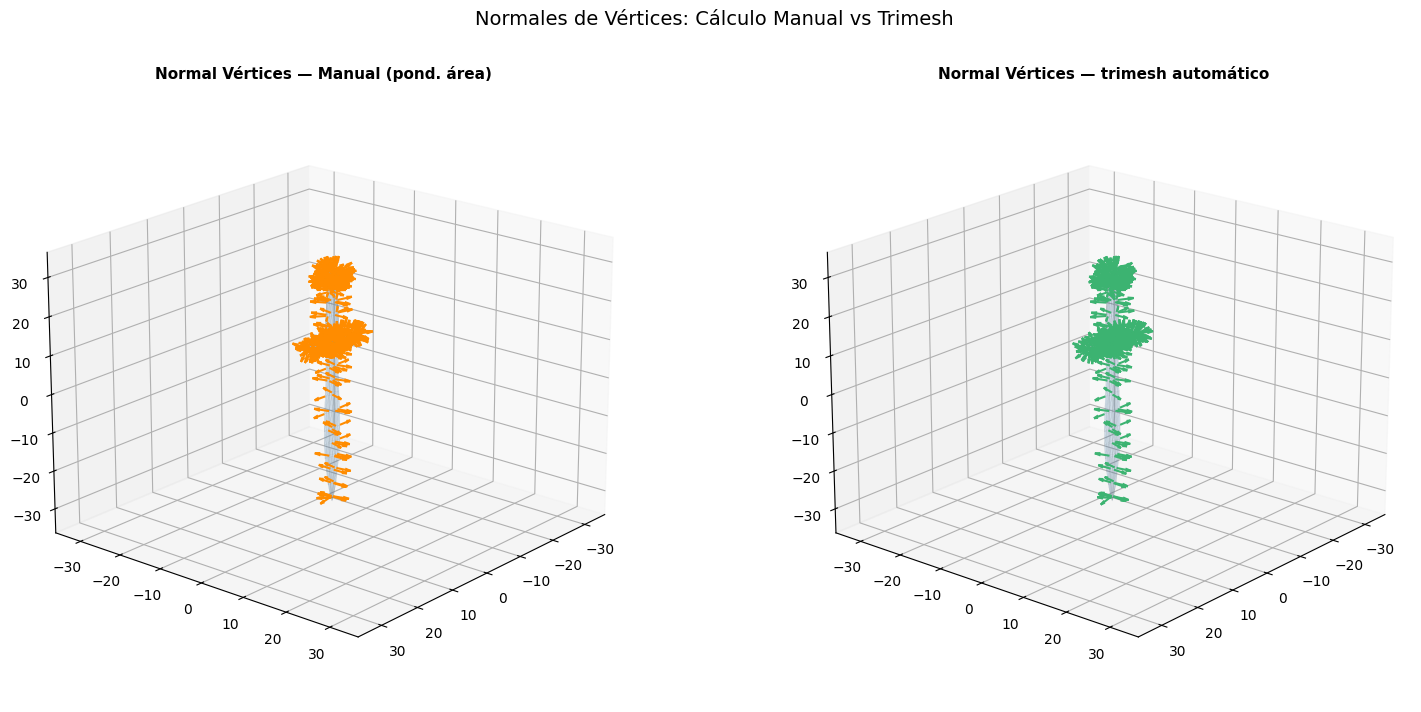

In [68]:
def plot_vertex_normals_comparison(vertices, faces, vn_manual, vn_trimesh, sample_n=100, scale=0.12):
    """Compara normales de vértices: manual vs trimesh."""
    rng = np.random.default_rng(0)
    idx = rng.choice(len(vertices), size=min(sample_n, len(vertices)), replace=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                              subplot_kw={'projection': '3d'})
    titles   = ['Normal Vértices — Manual (pond. área)', 'Normal Vértices — trimesh automático']
    normals_ = [vn_manual, vn_trimesh]
    colors   = ['darkorange', 'mediumseagreen']

    min_coords = vertices.min(axis=0)
    max_coords = vertices.max(axis=0)
    range_coords = max_coords - min_coords
    max_range = np.max(range_coords)
    center = (min_coords + max_coords) / 2
    padding = max_range * 0.1 # Small padding

    for ax, title, vn, col in zip(axes, titles, normals_, colors):
        poly = Poly3DCollection(
            [vertices[f] for f in faces],
            alpha=0.12, facecolor='steelblue', edgecolor='gray', linewidth=0.2
        )
        ax.add_collection3d(poly)

        origins = vertices[idx]
        dirs    = vn[idx] * scale
        ax.quiver(
            origins[:, 0], origins[:, 1], origins[:, 2],
            dirs[:, 0],    dirs[:, 1],    dirs[:, 2],
            color=col, linewidth=1.5, arrow_length_ratio=0.4
        )

        ax.set_xlim(center[0] - max_range/2 - padding, center[0] + max_range/2 + padding)
        ax.set_ylim(center[1] - max_range/2 - padding, center[1] + max_range/2 + padding)
        ax.set_zlim(center[2] - max_range/2 - padding, center[2] + max_range/2 + padding)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.view_init(elev=20, azim=40)

    plt.suptitle('Normales de Vértices: Cálculo Manual vs Trimesh', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_vertex_normals_comparison(vertices, faces,
                                vertex_normals_manual,
                                vertex_normals_trimesh, sample_n=500, scale=3.0)


---
## 4. Flat Shading vs Smooth Shading (lado a lado)

Se simula iluminación tipo Phong usando el modelo Lambertiano:
$$I = \max(\vec{n} \cdot \vec{L},\, 0)$$

- **Flat shading**: una normal por cara → aspecto facetado
- **Smooth shading**: normal interpolada por vértice → aspecto suavizado

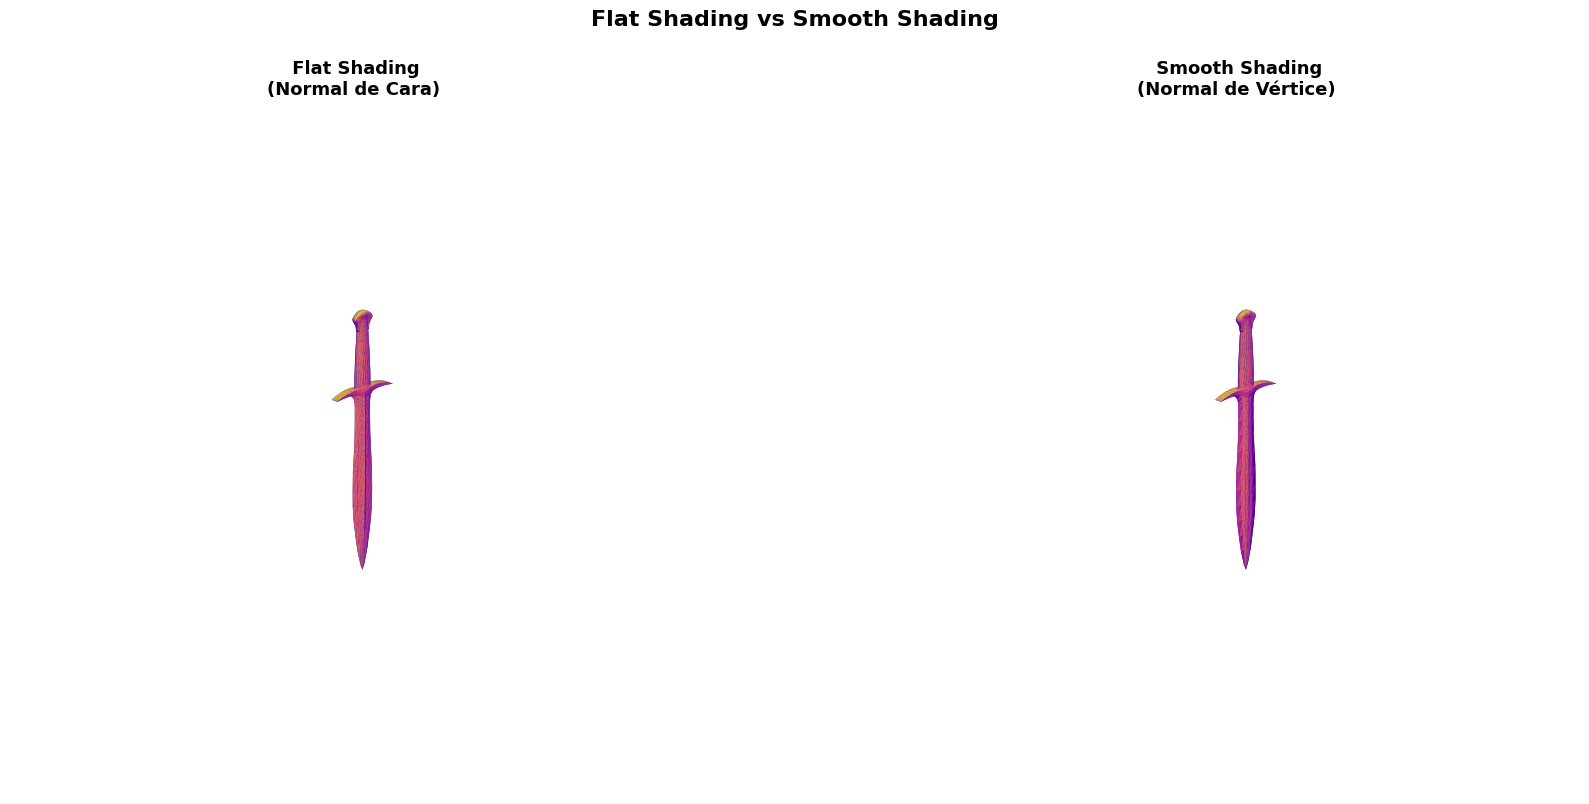

In [72]:
def lambertian_intensity(normals, light_dir):
    """Calcula intensidad Lambertiana: I = max(n·L, 0)"""
    L = np.array(light_dir, dtype=float)
    L /= np.linalg.norm(L)
    intensity = np.einsum('ij,j->i', normals, L)  # producto punto vectorizado
    return np.clip(intensity, 0.0, 1.0)  # ambient = 0.0


def shade_mesh(vertices, faces, normals_per_face, normals_per_vertex,
               light_dir=(1.0, 1.5, 2.0), colormap='plasma'):
    """
    Renderiza el mesh con Flat y Smooth shading lado a lado.
    """
    cmap = plt.get_cmap(colormap)

    # ── FLAT: una intensidad por cara ──────────────────────────────
    flat_intensity = lambertian_intensity(normals_per_face, light_dir)  # (M,)
    flat_colors    = cmap(flat_intensity)  # (M, 4) RGBA

    # ── SMOOTH: promedio de intensidades en vértices de cada cara ──
    vert_intensity  = lambertian_intensity(normals_per_vertex, light_dir)  # (N,)
    smooth_intensity = vert_intensity[faces].mean(axis=1)  # (M,) media por cara
    smooth_colors    = cmap(smooth_intensity)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                              subplot_kw={'projection': '3d'})

    min_coords = vertices.min(axis=0)
    max_coords = vertices.max(axis=0)
    range_coords = max_coords - min_coords
    max_range = np.max(range_coords)
    center = (min_coords + max_coords) / 2
    padding = max_range * 0.1 # Small padding

    for ax, face_colors, title in zip(
        axes,
        [flat_colors, smooth_colors],
        [' Flat Shading\n(Normal de Cara)', ' Smooth Shading\n(Normal de Vértice)']
    ):
        tri_list = [vertices[f] for f in faces]
        poly = Poly3DCollection(
            tri_list,
            facecolors=face_colors,
            edgecolor='none',
            alpha=1.0
        )
        ax.add_collection3d(poly)

        ax.set_xlim(center[0] - max_range/2 - padding, center[0] + max_range/2 + padding)
        ax.set_ylim(center[1] - max_range/2 - padding, center[1] + max_range/2 + padding)
        ax.set_zlim(center[2] - max_range/2 - padding, center[2] + max_range/2 + padding)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_axis_off()
        ax.view_init(elev=20, azim=45)

    plt.suptitle('Flat Shading vs Smooth Shading', fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()

    return flat_intensity, smooth_intensity


flat_i, smooth_i = shade_mesh(
    vertices, faces,
    face_normals_manual, vertex_normals_manual,
    light_dir=(1.0, 1.5, 2.5)
)


### 4.1 Análisis estadístico de las intensidades

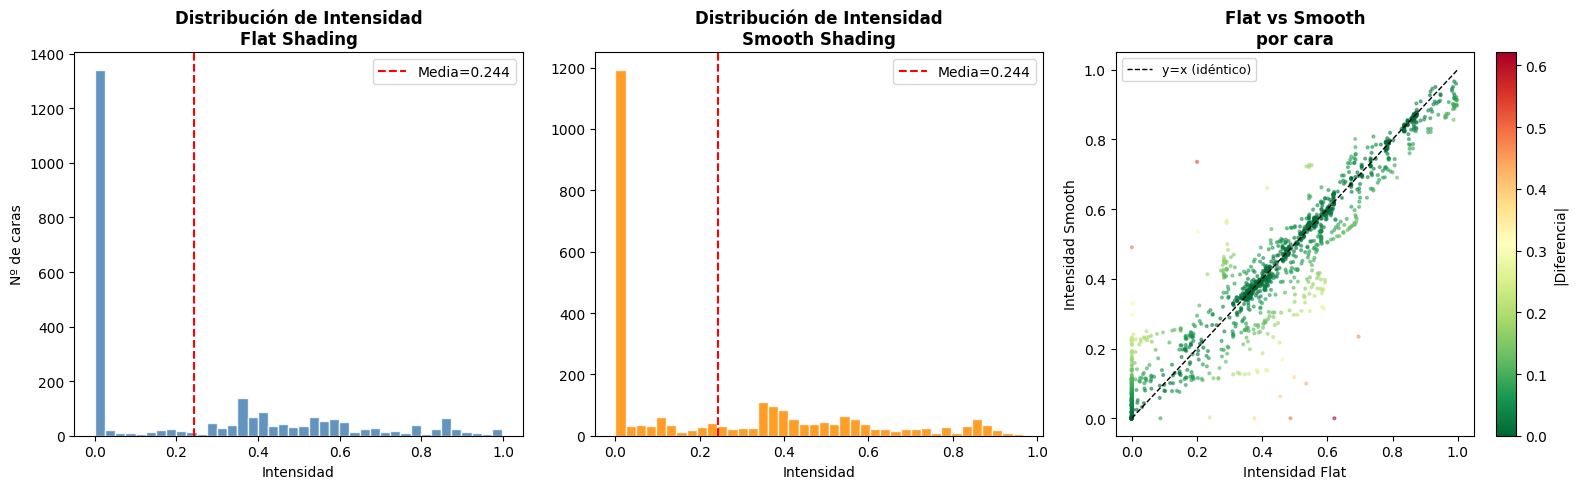

 Diferencia media  |Flat - Smooth|: 0.03022
   Diferencia máx    |Flat - Smooth|: 0.62149
   Desv. estándar    Flat  : 0.29566
   Desv. estándar    Smooth: 0.28440


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma Flat
axes[0].hist(flat_i, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Intensidad\nFlat Shading', fontweight='bold')
axes[0].set_xlabel('Intensidad')
axes[0].set_ylabel('Nº de caras')
axes[0].axvline(flat_i.mean(), color='red', linestyle='--', label=f'Media={flat_i.mean():.3f}')
axes[0].legend()

# Histograma Smooth
axes[1].hist(smooth_i, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución de Intensidad\nSmooth Shading', fontweight='bold')
axes[1].set_xlabel('Intensidad')
axes[1].axvline(smooth_i.mean(), color='red', linestyle='--', label=f'Media={smooth_i.mean():.3f}')
axes[1].legend()

# Scatter de diferencias
diff = np.abs(flat_i - smooth_i)
axes[2].scatter(flat_i, smooth_i, c=diff, cmap='RdYlGn_r', s=4, alpha=0.5)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='y=x (idéntico)')
axes[2].set_xlabel('Intensidad Flat')
axes[2].set_ylabel('Intensidad Smooth')
axes[2].set_title('Flat vs Smooth\npor cara', fontweight='bold')
axes[2].legend(fontsize=9)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(diff.min(), diff.max()))
plt.colorbar(sm, ax=axes[2], label='|Diferencia|')

plt.tight_layout()
plt.show()

print(f' Diferencia media  |Flat - Smooth|: {diff.mean():.5f}')
print(f'   Diferencia máx    |Flat - Smooth|: {diff.max():.5f}')
print(f'   Desv. estándar    Flat  : {flat_i.std():.5f}')
print(f'   Desv. estándar    Smooth: {smooth_i.std():.5f}')


---
## 5. Validación y Corrección de Normales

Se comprueban cuatro condiciones:
1. Magnitud unitaria (‖n‖ ≈ 1)
2. Ausencia de NaN/Inf
3. Orientación hacia afuera
4. Consistencia global de orientación (winding order)

In [74]:
def validate_and_fix_normals(vertices, faces, face_normals, tol=1e-5):
    """
    Valida y corrige normales de caras.

    Returns
    -------
    fixed_normals   : (M, 3)  normales corregidas
    report          : dict    resumen de validación
    """
    report = {}
    fixed  = face_normals.copy()

    # ── 1. Magnitud unitaria ────────────────────────────────────────
    magnitudes = np.linalg.norm(fixed, axis=1)  # (M,)
    bad_mag    = np.abs(magnitudes - 1.0) > tol
    report['magnitud_unitaria'] = {
        'total'     : len(magnitudes),
        'incorrectas': int(bad_mag.sum()),
        'min_mag'   : float(magnitudes.min()),
        'max_mag'   : float(magnitudes.max()),
    }
    # Corregir renormalizando
    if bad_mag.any():
        safe = np.where(magnitudes == 0, 1e-10, magnitudes)
        fixed = fixed / safe[:, np.newaxis]

    # ── 2. NaN / Inf ────────────────────────────────────────────────
    has_nan  = np.isnan(fixed).any(axis=1)
    has_inf  = np.isinf(fixed).any(axis=1)
    report['nan_inf'] = {
        'nan_count': int(has_nan.sum()),
        'inf_count': int(has_inf.sum())
    }
    # Reemplazar normales problemáticas por (0,0,1)
    bad_vals = has_nan | has_inf
    if bad_vals.any():
        fixed[bad_vals] = np.array([0.0, 0.0, 1.0])

    # ── 3. Orientación hacia afuera ─────────────────────────────────
    A = vertices[faces[:, 0]]
    B = vertices[faces[:, 1]]
    C = vertices[faces[:, 2]]
    centroids_f    = (A + B + C) / 3.0
    mesh_centroid  = vertices.mean(axis=0)
    outward_vec    = centroids_f - mesh_centroid
    dot_out        = np.sum(outward_vec * fixed, axis=1)
    inverted       = dot_out < 0
    report['orientacion'] = {
        'invertidas' : int(inverted.sum()),
        'correctas'  : int((~inverted).sum())
    }
    # Invertir normales incorrectas
    fixed[inverted] *= -1

    # ── 4. Consistencia (vecindad entre caras) ──────────────────────
    # Para cada arista compartida, las normales de las caras deben tener
    # dot > 0 si el mesh es suave / consistente.
    # Construimos el grafo de adyacencia con trimesh si está disponible.
    try:
        import trimesh as _tr
        tmp = _tr.Trimesh(vertices=vertices, faces=faces, process=False)
        adj = tmp.face_adjacency  # (K, 2) pares de caras adyacentes
        dot_adj = np.sum(fixed[adj[:, 0]] * fixed[adj[:, 1]], axis=1)
        inconsistent = (dot_adj < 0).sum()
        report['consistencia'] = {
            'pares_adyacentes'   : len(adj),
            'pares_inconsistentes': int(inconsistent),
            'consistencia_pct'   : float(100 * (1 - inconsistent / max(len(adj), 1)))
        }
    except Exception:
        report['consistencia'] = {'nota': 'trimesh no disponible para análisis de adyacencia'}

    return fixed, report


face_normals_fixed, validation_report = validate_and_fix_normals(
    vertices, faces, face_normals_manual
)

print('=' * 55)
print('         REPORTE DE VALIDACIÓN DE NORMALES')
print('=' * 55)

r = validation_report
print(f"\n Magnitud unitaria")
print(f"   Normales incorrectas : {r['magnitud_unitaria']['incorrectas']} / {r['magnitud_unitaria']['total']}")
print(f"   Rango de magnitudes  : [{r['magnitud_unitaria']['min_mag']:.7f}, {r['magnitud_unitaria']['max_mag']:.7f}]")

print(f"\n⚠️  NaN / Inf")
print(f"   NaN: {r['nan_inf']['nan_count']}  |  Inf: {r['nan_inf']['inf_count']}")

print(f"\n Orientación")
print(f"   Invertidas (corregidas): {r['orientacion']['invertidas']}")
print(f"   Correctas              : {r['orientacion']['correctas']}")

if 'consistencia_pct' in r['consistencia']:
    print(f"\n Consistencia entre caras adyacentes")
    print(f"   Pares adyacentes      : {r['consistencia']['pares_adyacentes']}")
    print(f"   Pares inconsistentes  : {r['consistencia']['pares_inconsistentes']}")
    print(f"   Consistencia global   : {r['consistencia']['consistencia_pct']:.2f}%")
print('=' * 55)

         REPORTE DE VALIDACIÓN DE NORMALES

 Magnitud unitaria
   Normales incorrectas : 0 / 2596
   Rango de magnitudes  : [1.0000000, 1.0000000]

⚠️  NaN / Inf
   NaN: 0  |  Inf: 0

 Orientación
   Invertidas (corregidas): 601
   Correctas              : 1995

 Consistencia entre caras adyacentes
   Pares adyacentes      : 3828
   Pares inconsistentes  : 196
   Consistencia global   : 94.88%


### 5.1 Visualización del mapa de anomalías

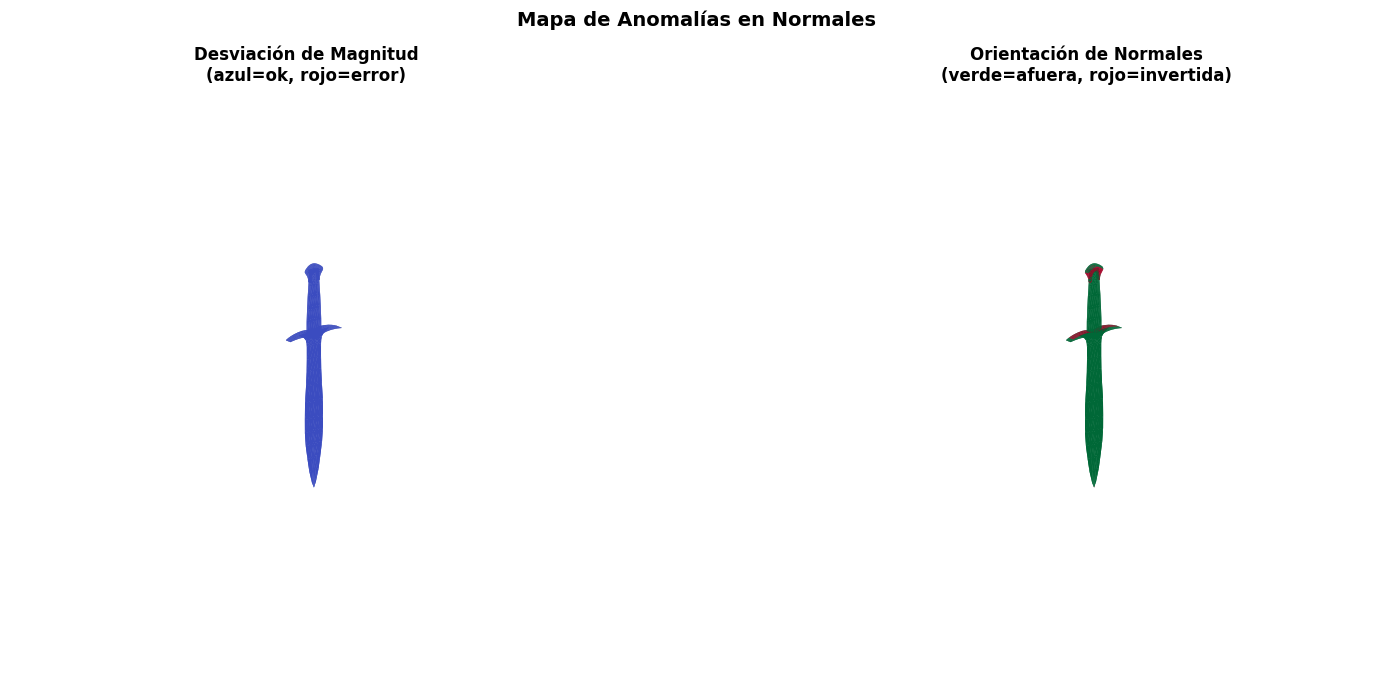

In [75]:
def plot_normal_anomalies(vertices, faces, face_normals):
    """Colorea caras según la desviación de magnitud y orientación."""
    magnitudes = np.linalg.norm(face_normals, axis=1)

    A = vertices[faces[:, 0]]
    B = vertices[faces[:, 1]]
    C = vertices[faces[:, 2]]
    centroids_f   = (A + B + C) / 3.0
    mesh_centroid = vertices.mean(axis=0)
    dot_out       = np.sum((centroids_f - mesh_centroid) * face_normals, axis=1)
    orientation_ok = (dot_out > 0).astype(float)  # 1=buena, 0=invertida

    fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                              subplot_kw={'projection': '3d'})

    min_coords = vertices.min(axis=0)
    max_coords = vertices.max(axis=0)
    range_coords = max_coords - min_coords
    max_range = np.max(range_coords)
    center = (min_coords + max_coords) / 2
    padding = max_range * 0.1 # Small padding

    # Panel izquierdo: mapa de magnitudes
    cmap1  = plt.get_cmap('coolwarm')
    dev    = np.abs(magnitudes - 1.0)
    norm1  = plt.Normalize(dev.min(), max(dev.max(), 1e-7))
    colors1 = cmap1(norm1(dev))
    poly1   = Poly3DCollection([vertices[f] for f in faces],
                                facecolors=colors1, edgecolor='none', alpha=1.0)
    axes[0].add_collection3d(poly1)
    axes[0].set_title('Desviación de Magnitud\n(azul=ok, rojo=error)', fontweight='bold')
    axes[0].set_axis_off()
    axes[0].view_init(elev=20, azim=50)

    # Panel derecho: orientación
    cmap2   = plt.get_cmap('RdYlGn')
    colors2 = cmap2(orientation_ok)
    poly2   = Poly3DCollection([vertices[f] for f in faces],
                                facecolors=colors2, edgecolor='none', alpha=1.0)
    axes[1].add_collection3d(poly2)
    axes[1].set_title('Orientación de Normales\n(verde=afuera, rojo=invertida)', fontweight='bold')
    axes[1].set_axis_off()
    axes[1].view_init(elev=20, azim=50)

    for ax in axes:
        ax.set_xlim(center[0] - max_range/2 - padding, center[0] + max_range/2 + padding)
        ax.set_ylim(center[1] - max_range/2 - padding, center[1] + max_range/2 + padding)
        ax.set_zlim(center[2] - max_range/2 - padding, center[2] + max_range/2 + padding)

    plt.suptitle('Mapa de Anomalías en Normales', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_normal_anomalies(vertices, faces, face_normals_manual)


---
## 6. Resumen Final

In [76]:
print('━' * 60)
print('              RESUMEN DEL ANÁLISIS')
print('━' * 60)

print(f'\n Modelo')
print(f'   Vértices : {len(vertices):,}')
print(f'   Caras    : {len(faces):,}')

print(f'\n Normales de Caras (manual vs trimesh)')
dot_f = np.sum(face_normals_manual * np.array(mesh.face_normals), axis=1)
print(f'   Coincidencia > 99.9% : {(dot_f > 0.999).mean()*100:.1f}% de las caras')

print(f'\n Normales de Vértices (manual vs trimesh)')
dot_vv = np.sum(vertex_normals_manual * np.array(mesh.vertex_normals), axis=1)
print(f'   Coincidencia > 99%   : {(dot_vv > 0.99).mean()*100:.1f}% de los vértices')

print(f'\n Shading')
print(f'   Flat  — intensidad media : {flat_i.mean():.4f}  std: {flat_i.std():.4f}')
print(f'   Smooth— intensidad media : {smooth_i.mean():.4f}  std: {smooth_i.std():.4f}')
print(f'   Diferencia media absoluta: {np.abs(flat_i - smooth_i).mean():.5f}')

print(f'\n✅ Validación')
r = validation_report
print(f'   Normales con magnitud incorrecta : {r["magnitud_unitaria"]["incorrectas"]}')
print(f'   Normales con NaN/Inf             : {r["nan_inf"]["nan_count"] + r["nan_inf"]["inf_count"]}')
print(f'   Normales invertidas (corregidas) : {r["orientacion"]["invertidas"]}')
if 'consistencia_pct' in r['consistencia']:
    print(f'   Consistencia entre adyacentes    : {r["consistencia"]["consistencia_pct"]:.2f}%')

print('━' * 60)
print('✔  Pipeline completo ejecutado exitosamente.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              RESUMEN DEL ANÁLISIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Modelo
   Vértices : 1,361
   Caras    : 2,596

 Normales de Caras (manual vs trimesh)
   Coincidencia > 99.9% : 100.0% de las caras

 Normales de Vértices (manual vs trimesh)
   Coincidencia > 99%   : 77.9% de los vértices

 Shading
   Flat  — intensidad media : 0.2441  std: 0.2957
   Smooth— intensidad media : 0.2436  std: 0.2844
   Diferencia media absoluta: 0.03022

✅ Validación
   Normales con magnitud incorrecta : 0
   Normales con NaN/Inf             : 0
   Normales invertidas (corregidas) : 601
   Consistencia entre adyacentes    : 94.88%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✔  Pipeline completo ejecutado exitosamente.
